In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score,classification_report

In [2]:
df=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df=df.drop('customerID',axis=1)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [6]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors="coerce")

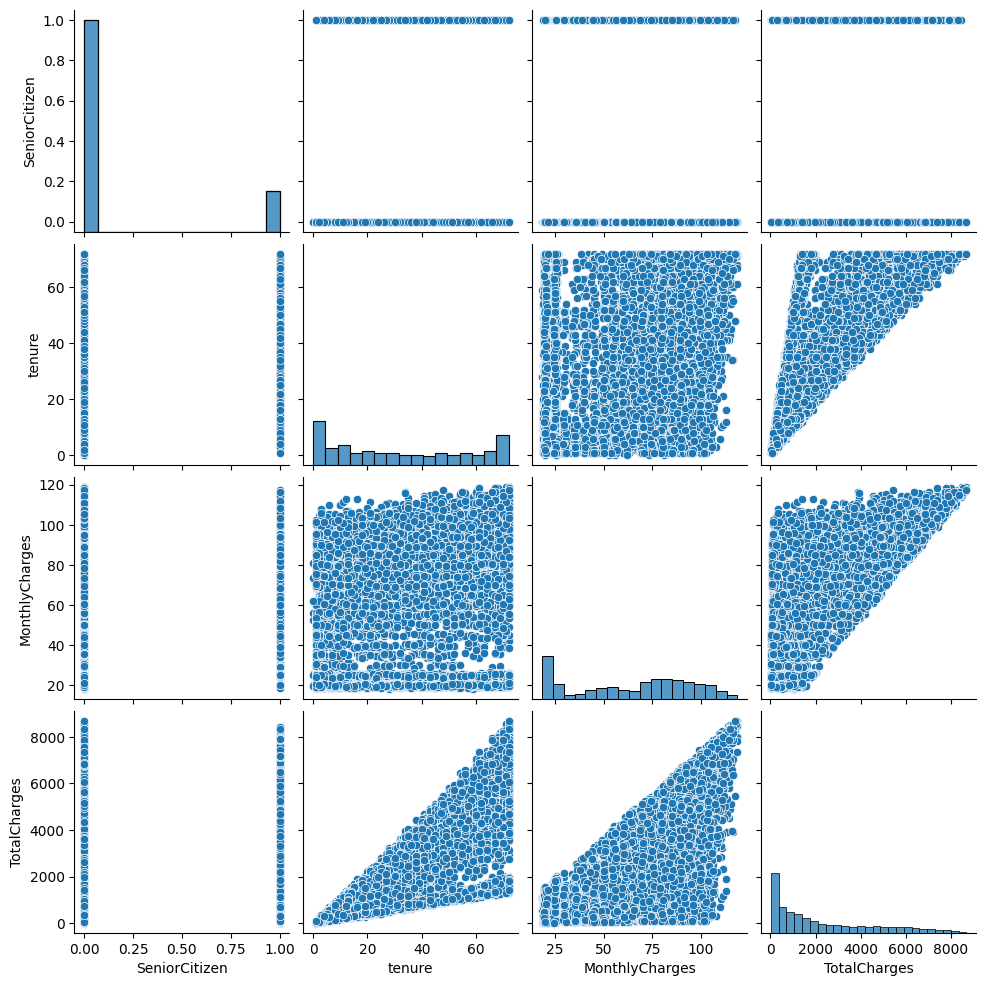

In [7]:
sns.pairplot(df)

In [8]:
n_col=[]
o_col=[]
for column in df.columns:
  if df[column].dtype!='object':
    n_col.append(column)
  else:
    o_col.append(column)

In [9]:
df[n_col]=np.log1p(df[n_col])

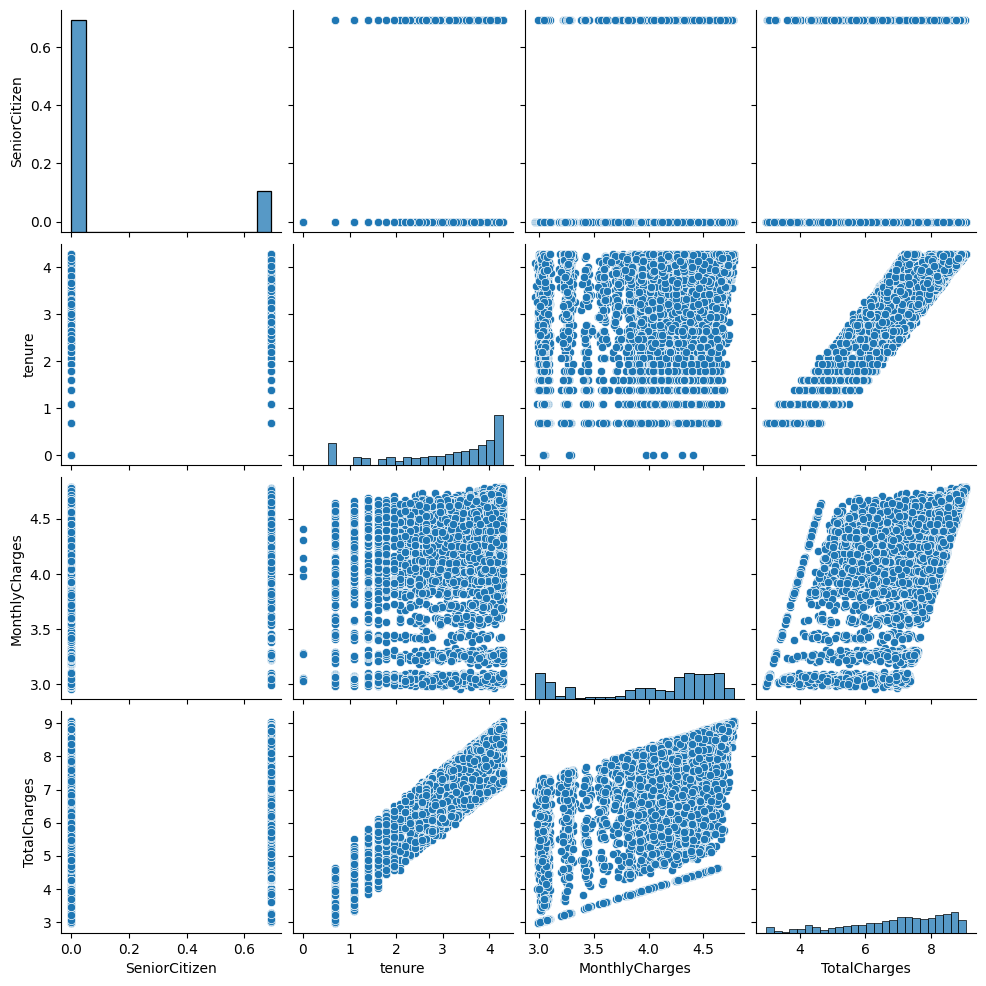

In [10]:
sns.pairplot(df)

In [11]:
df=pd.get_dummies(df,dtype=int)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 47 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            7043 non-null   float64
 1   tenure                                   7043 non-null   float64
 2   MonthlyCharges                           7043 non-null   float64
 3   TotalCharges                             7032 non-null   float64
 4   gender_Female                            7043 non-null   int64  
 5   gender_Male                              7043 non-null   int64  
 6   Partner_No                               7043 non-null   int64  
 7   Partner_Yes                              7043 non-null   int64  
 8   Dependents_No                            7043 non-null   int64  
 9   Dependents_Yes                           7043 non-null   int64  
 10  PhoneService_No                          7043 no

In [13]:
df = df.drop(columns=['Churn_No','StreamingMovies_Yes','StreamingTV_Yes','PaperlessBilling_No','StreamingTV_Yes','TechSupport_Yes','DeviceProtection_Yes','OnlineBackup_Yes','OnlineSecurity_Yes','PhoneService_No','Dependents_No','Partner_No','gender_Female'], axis=1)

In [14]:
for column in df.columns:
  if df[column].dtype=='int64':
    print(f"{column},{df[column].value_counts()}")

gender_Male,gender_Male
1    3555
0    3488
Name: count, dtype: int64
Partner_Yes,Partner_Yes
0    3641
1    3402
Name: count, dtype: int64
Dependents_Yes,Dependents_Yes
0    4933
1    2110
Name: count, dtype: int64
PhoneService_Yes,PhoneService_Yes
1    6361
0     682
Name: count, dtype: int64
MultipleLines_No,MultipleLines_No
0    3653
1    3390
Name: count, dtype: int64
MultipleLines_No phone service,MultipleLines_No phone service
0    6361
1     682
Name: count, dtype: int64
MultipleLines_Yes,MultipleLines_Yes
0    4072
1    2971
Name: count, dtype: int64
InternetService_DSL,InternetService_DSL
0    4622
1    2421
Name: count, dtype: int64
InternetService_Fiber optic,InternetService_Fiber optic
0    3947
1    3096
Name: count, dtype: int64
InternetService_No,InternetService_No
0    5517
1    1526
Name: count, dtype: int64
OnlineSecurity_No,OnlineSecurity_No
0    3545
1    3498
Name: count, dtype: int64
OnlineSecurity_No internet service,OnlineSecurity_No internet service
0    5517


In [15]:
y=df['Churn_Yes']
X=df.drop('Churn_Yes',axis=1)
norm=MinMaxScaler()
X=norm.fit_transform(X)
ros=RandomOverSampler()
X,y=ros.fit_resample(X,y)

In [16]:
x_train,x_test,y_train,y_test=train_test_split(X,y,random_state=42)

In [17]:
model=RandomForestClassifier()

In [18]:
model.fit(x_train,y_train)

RandomForestClassifier()

In [19]:
y_pred=model.predict(x_test)

In [20]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.85      0.89      1298
           1       0.86      0.94      0.90      1289

    accuracy                           0.90      2587
   macro avg       0.90      0.90      0.90      2587
weighted avg       0.90      0.90      0.90      2587



In [22]:
with open('model.pk1','wb') as file:
  pickle.dump(model,file)